Ensemble de ville avec distances

trouver le plus petit chemin qui relie toutes les villes sans passer par une ville plus d'une fois.



3 heuristique 

plus proche voisin

k-opt 

algorithme génétique

1 individu = une solution possible (une parcours de villes) , genere 100 parcours differents , une fonction d'evaluation (le cout du parcours) , selectionne les meilleurs parcours , croisement (melange de 2 parcours pour en faire un nouveau) , mutation (changer l'ordre de 2 villes dans le parcours)

à la fin afficher le parcours le plus court trouvé et sa distance totale.

# TSP (Travelling Salesman Problem)

In [1]:
import pandas as pd
import polars as pl
import numpy as np
import time

from pprint import pprint

from tsp.io import load_cities, process_pays_travel
from tsp.structure import Pays
from tsp.solvers import TwoOpt 

Distance totale partant de Alger : 89.65243749735936
Distance totale partant de Oran : 91.61155818127078
Distance totale partant de Constantine : 86.50474542473842
Distance totale partant de Annaba : 89.49718314888904
Distance totale partant de Blida : 89.72895275047816
Distance totale partant de Batna : 89.58317848260623
Distance totale partant de Sétif : 85.71026961089458
Distance totale partant de Tlemcen : 89.4649927343156
Distance totale partant de Sidi Bel Abbès : 91.37250206373973
Distance totale partant de Biskra : 89.22368647215109
Distance totale partant de Djelfa : 86.74088742708408
Distance totale partant de Béjaïa : 96.95382798851784
Distance totale partant de Skikda : 86.35213302313464
Distance totale partant de Tébessa : 87.33744086145855
Distance totale partant de M'Sila : 97.37737032308884
Distance totale partant de Ouargla : 89.77657169901934
Distance totale partant de Tiaret : 88.09253327822371
Distance totale partant de Chlef : 88.57998968127526
Distance totale part

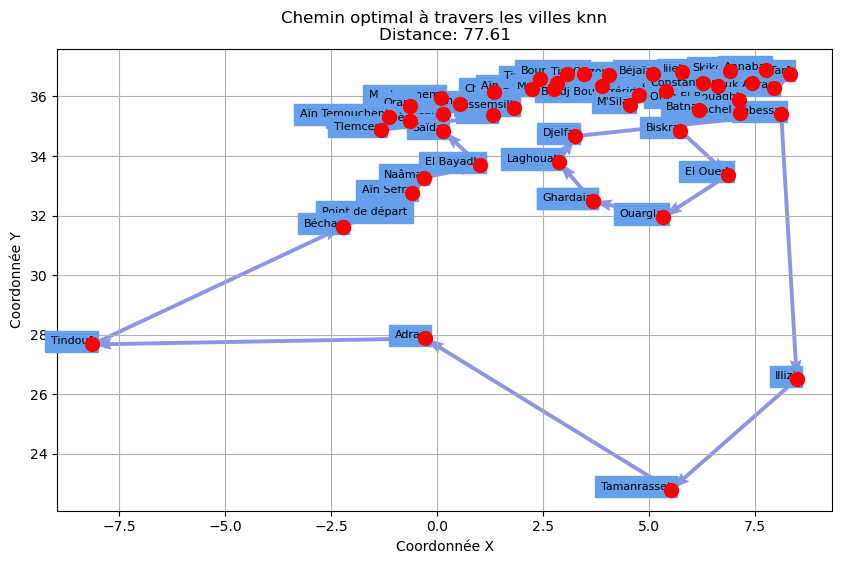

In [2]:
liste_dz = load_cities("../data/dz-50.csv", separator=";")


algerie50 = Pays("Algérie", liste_dz)
algerie50.get_matrix_with_labels()
algerie50.compute_all_paths()
algerie50.print_distance_from_each_city()
algerie50.get_optimal_path()
algerie50.print_distance_from_each_city()
algerie50.plot_path_knn()

In [3]:
pprint(algerie50.__dict__) # affiche les attributs de l'objet algerie50

{'best_path_knn': ['Béchar',
                   'Aïn Séfra',
                   'Naâma',
                   'El Bayadh',
                   'Saïda',
                   'Mascara',
                   'Relizane',
                   'Mostaganem',
                   'Oran',
                   'Sidi Bel Abbès',
                   'Aïn Temouchent',
                   'Tlemcen',
                   'Tiaret',
                   'Tissemsilt',
                   'Chlef',
                   'Aïn Defla',
                   'Tipaza',
                   'Blida',
                   'Médéa',
                   'Alger',
                   'Boumerdès',
                   'Tizi Ouzou',
                   'Bouira',
                   'Bordj Bou Arréridj',
                   "M'Sila",
                   'Sétif',
                   'Béjaïa',
                   'Jijel',
                   'Mila',
                   'Constantine',
                   'Skikda',
                   'Guelma',
                   'Sou

In [4]:
# print(algerie50.best_path_knn)

# nouveau_path = algerie50.two_opt.compute_path_distance(algerie50.best_path_knn, algerie50.matrix_df)

# print(nouveau_path)

# all(x == y for x, y in zip(algerie50.best_path_knn , nouveau_path))


In [5]:
france100 = process_pays_travel("../data/fr-100.csv", "france")
# france100.plot_path()

--- Analyse terminée pour : ../data/fr-100.csv ---

Chemin trouvés :

Meilleur chemin trouvé avec KNN:
Point de départ: Versailles
Chemin: ['Versailles', 'Rueil-Malmaison', 'Nanterre', 'Courbevoic', 'Neuilly-sur-Seine', 'Levallois-Perret', 'Clichy', 'Saint-Ouen', 'Saint-Denis', 'Aubervilliers', 'Pantin', 'Bellevue', 'Paris', 'Ivry-sur-Seine', 'Villejuif', 'Vitry-sur-Seine', 'Maisons-Alfort', 'Créteil', 'Saint-Maur-des-Fossés', 'Champigny-sur-Marne', 'Noisy-le-Grand', 'Chelles', 'Sevran', 'Aulnay-sous-Bois', 'Le Blanc-Mesnil', 'Drancy', 'Bobigny', 'Bondy', 'Montreuil', 'Sarcelles', 'Épinay-sur-Seine', 'Argenteuil', 'Colombes', 'Boulogne-Billancourt', 'Issy-les-Moulineaux', 'Clamart', 'Antony', 'Évry', 'Corbeil-Essonnes', 'Meaux', 'Cergy', 'Beauvais', 'Amiens', 'Saint-Quentin', 'Lille', 'Roubaix', 'Tourcoing', 'Dunkerque', 'Calais', 'Rouen', 'Le Havre', 'Caen', 'Le Mans', 'Tours', 'Poitiers', 'Limoges', 'Clermont-Ferrand', 'Saint-Étienne', 'Lyon', 'Villeurbanne', 'Vaulx-en-Velin', 'Vénis

In [6]:
france50 = process_pays_travel("../data/fr-50.csv", "france")

france50.compute_all_paths()
start, path, dist = france50.get_optimal_path()

# 3. Maintenant on peut appeler le TwoOpt
# L'appel automatique passe (self, path) -> 2 arguments, c'est parfait.

d = france50.two_opt.two_opt(france50.best_path_knn)
print(f"Distance two-opt : {d}")

--- Analyse terminée pour : ../data/fr-50.csv ---

Chemin trouvés :

Meilleur chemin trouvé avec KNN:
Point de départ: Créteil
Chemin: ['Créteil', 'Vitry-sur-Seine', 'Paris', 'Aubervilliers', 'Saint-Denis', 'Colombes', 'Argenteuil', 'Nanterre', 'Boulogne-Billancourt', 'Montreuil', 'Aulnay-sous-Bois', 'Amiens', 'Lille', 'Roubaix', 'Tourcoing', 'Dunkerque', 'Rouen', 'Le Havre', 'Caen', 'Le Mans', 'Tours', 'Poitiers', 'Limoges', 'Clermont-Ferrand', 'Saint-Étienne', 'Lyon', 'Villeurbanne', 'Grenoble', 'Annecy', 'Besançon', 'Dijon', 'Nancy', 'Metz', 'Strasbourg', 'Mulhouse', 'Reims', 'Orléans', 'Angers', 'Nantes', 'Rennes', 'Brest', 'Bordeaux', 'Toulouse', 'Perpignan', 'Montpellier', 'Nîmes', 'Aix-en-Provence', 'Marseille', 'Toulon', 'Nice', 'Créteil']
Distance KNN: 59.50

Meilleur chemin trouvé avec 2-opt:
Chemin: ['Créteil', 'Montreuil', 'Aulnay-sous-Bois', 'Aubervilliers', 'Paris', 'Saint-Denis', 'Argenteuil', 'Colombes', 'Nanterre', 'Boulogne-Billancourt', 'Vitry-sur-Seine', 'Orléans', 

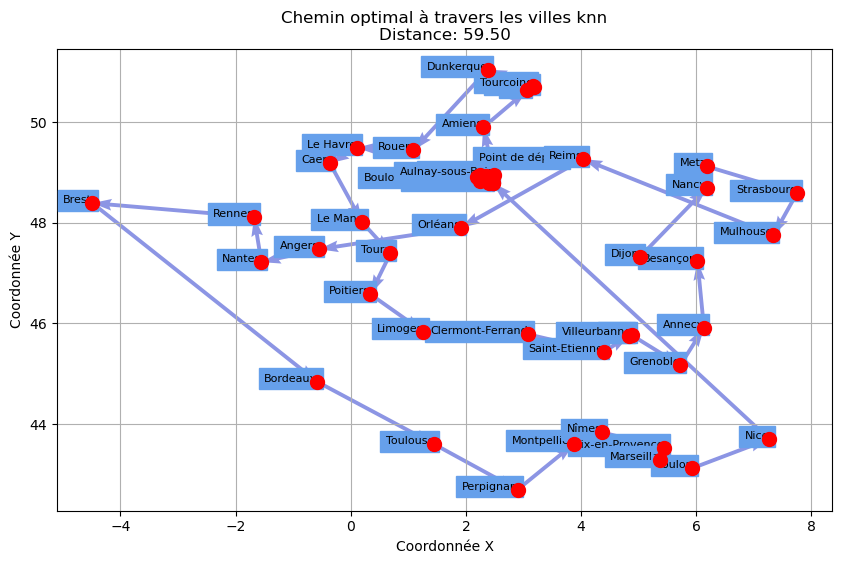

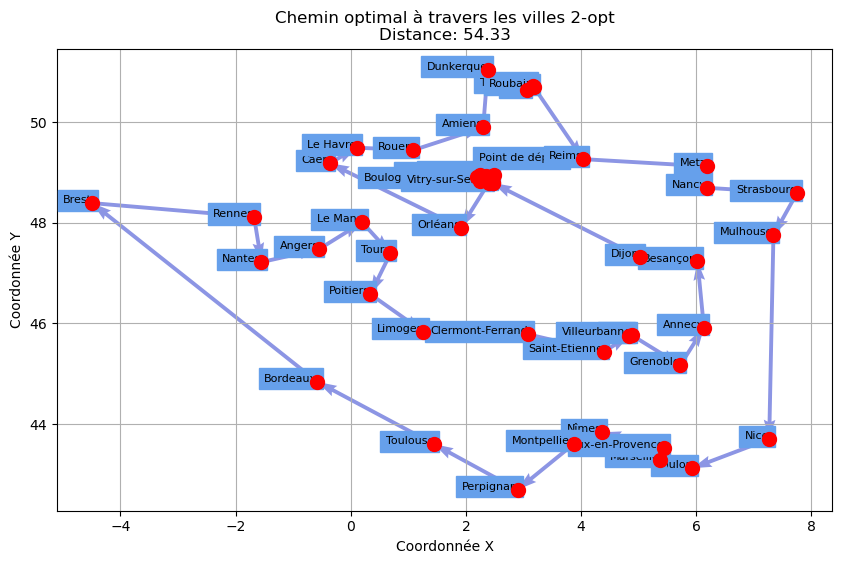

In [7]:
france50.plot_path_knn()

# plot avec two-opt


france50.get_optimal_path()
france50.plot_path_two_opt()

In [8]:
france10 = process_pays_travel("../data/fr-10.csv", "france",show_matrix=True)

france10.two_opt.three_opt(france10.best_path_two_opt)

--- Analyse terminée pour : ../data/fr-10.csv ---

Matrice de distances :
                Paris  Bordeaux  Marseille      Lyon  Toulouse      Nice  \
Paris        0.000000  4.973095   6.326457  3.972241  5.330144  7.120736   
Bordeaux     4.973095  0.000000   6.146967  5.497527  2.371294  7.928195   
Marseille    6.326457  6.146967   0.000000  2.519965  3.938071  1.939485   
Lyon         3.972241  5.497527   2.519965  0.000000  4.022312  3.180650   
Toulouse     5.330144  2.371294   3.938071  4.022312  0.000000  5.823140   
Nice         7.120736  7.928195   1.939485  3.180650  5.823140  0.000000   
Nantes       4.234859  2.569377   7.956437  6.556977  4.694562  9.493663   
Montpellier  5.462010  4.623296   1.525776  2.354000  2.433211  3.390335   
Strasbourg   5.400525  9.128595   5.796183  4.051505  8.031260  4.903401   
Lille        1.906665  6.836363   7.687222  5.183621  7.206435  8.102751   

               Nantes  Montpellier  Strasbourg     Lille  
Paris        4.234859     5.46

TypeError: unsupported operand type(s) for -: 'tuple' and 'tuple'

In [ ]:
france10.graph.get_dataframe()

,Paris,Bordeaux,Marseille,Lyon,Toulouse,Nice,Nantes,Montpellier,Strasbourg,Lille
Paris,0.000000,4.973095,6.326457,3.972241,5.330144,7.120736,4.234859,5.462010,5.400525,1.906665
Bordeaux,4.973095,0.000000,6.146967,5.497527,2.371294,7.928195,2.569377,4.623296,9.128595,6.836363
Marseille,6.326457,6.146967,0.000000,2.519965,3.938071,1.939485,7.956437,1.525776,5.796183,7.687222
Lyon,3.972241,5.497527,2.519965,0.000000,4.022312,3.180650,6.556977,2.354000,4.051505,5.183621
Toulouse,5.330144,2.371294,3.938071,4.022312,0.000000,5.823140,4.694562,2.433211,8.031260,7.206435
Nice,7.120736,7.928195,1.939485,3.180650,5.823140,0.000000,9.493663,3.390335,4.903401,8.102751
Nantes,4.234859,2.569377,7.956437,6.556977,4.694562,9.493663,0.000000,6.518403,9.398284,5.734832
Montpellier,5.462010,4.623296,1.525776,2.354000,2.433211,3.390335,6.518403,0.000000,6.299276,7.063530
Strasbourg,5.400525,9.128595,5.796183,4.051505,8.031260,4.903401,9.398284,6.299276,0.000000,5.113965
Lille,1.906665,6.836363,7.687222,5.183621,7.206435,8.102751,5.734832,7.063530,5.113965,0.000000


In [ ]:
print()
liste = [2.354000,2.433211,2.371294,2.569377,4.234859,1.906665,5.113965,4.903401,1.939485,2.519965]

print(sum(liste))


30.346221999999997


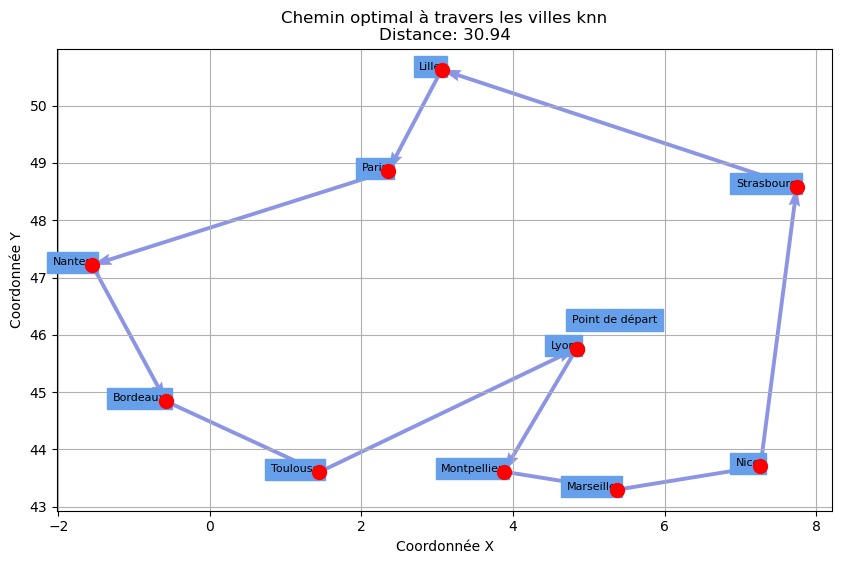

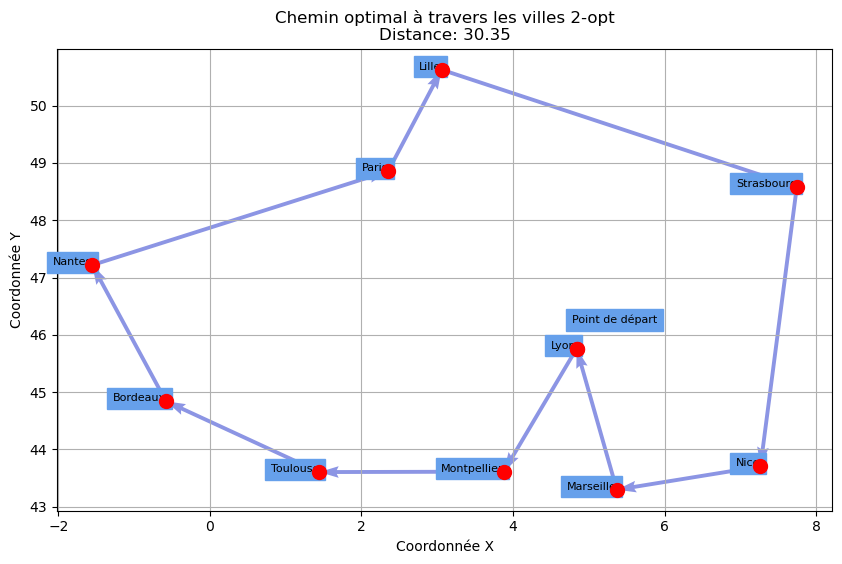

In [ ]:
france10.compute_all_paths()
france10.get_optimal_path()
france10.plot_path_knn()
france10.plot_path_two_opt()

In [ ]:

start = time.time()
df = pd.read_csv("../data/fr.csv", sep=";")

print(f"Temps de chargement avec pandas : {time.time() - start:.4f} secondes")

Temps de chargement avec pandas : 0.0013 secondes


In [ ]:
start = time.time()
df_pl = pl.read_csv("../data/fr.csv", separator=";")
print(f"Temps de chargement avec polars : {time.time() - start:.4f} secondes")

Temps de chargement avec polars : 0.0006 secondes


# Approche k-opt

In [ ]:

def test_twoopt_improvement():
    villes = load_cities("../data/fr-50.csv", separator=";")
    pays = Pays("Test", villes)
    pays.compute_all_paths()
    
    start, knn_path, knn_dist = pays.get_optimal_path()
    opt_path, opt_dist = pays.best_path_two_opt, pays.two_opt.distance_route(pays.best_path_two_opt)
    
    # 2-opt should never make path worse
    assert opt_dist <= knn_dist, f"2-opt degraded solution: {knn_dist} → {opt_dist}"
    print(f"✓ KNN: {knn_dist:.2f} → 2-OPT: {opt_dist:.2f} (improvement: {(knn_dist-opt_dist)/knn_dist*100:.1f}%)")

print(test_twoopt_improvement())

✓ KNN: 59.50 → 2-OPT: 54.33 (improvement: 8.7%)
None
